In [19]:
!pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn plotly scipy statsmodels imbalanced-learn ipykernel --quiet

In [20]:
# =============================================================================
# Aurora Finance — Banking Module: Task 1
# Stage 1: Predict PD (Ridge vs Lasso)
# Stage 2: Risk Scoring + Classification (Logistic vs Decision Tree)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_score
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             classification_report)

# =============================================================================
# 0. DATA PREPARATION [cite: 133-157]
# =============================================================================

# Load dataset: loan_portfolio.csv [cite: 134]
df = pd.read_csv('sample_data/loan_portfolio.csv')

# Feature Engineering: Creating ratios as per ML Strategy
df['Loan_to_Income'] = df['Loan_Amount'] / df['Annual_Income']
df['Customer_Type_enc'] = (df['Customer_Type'] == 'Retail').astype(int)

print("=" * 60)
print("AURORA FINANCE — BANKING MODULE: TASK 1")
print("=" * 60)
print(f"Dataset shape: {df.shape}")
print()


AURORA FINANCE — BANKING MODULE: TASK 1
Dataset shape: (100, 12)



In [21]:
df

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,Loan_to_Income,Customer_Type_enc
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,0.149281,0
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,0.301131,1
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,0.017208,0
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,0.022952,0
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,6.029358,1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Retail,478345,0.54,15,965614,12.57,60,0,0.30,2.018656,1
96,97,Corporate,779074,0.55,15,550677,4.80,12,0,0.11,0.706835,0
97,98,Corporate,3715501,0.80,24,656465,5.75,60,0,0.23,0.176683,0
98,99,Corporate,1909490,0.42,22,313571,11.67,60,0,0.12,0.164217,0


In [22]:

# =============================================================================
# STAGE 1 — REGRESSION: PREDICT PD
# =============================================================================

print("-" * 60)
print("STAGE 1: PD PREDICTION (REGRESSION)")
print("-" * 60)

FEATURES_REG = ['Annual_Income', 'Debt_to_Income', 'Credit_History_Length',
                'Loan_Amount', 'Interest_Rate', 'Loan_Term_Months',
                'Past_Default', 'Loan_to_Income', 'Customer_Type_enc']

X_reg = df[FEATURES_REG].values
y_reg = df['PD'].values

# Standardize features for linear models
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

loo = LeaveOneOut()

def loocv_regression(model, X, y):
    """Run Leave-One-Out CV for precise evaluation on small samples."""
    y_pred_all = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        model.fit(X[train_idx], y[train_idx])
        y_pred_all[test_idx] = model.predict(X[test_idx])
    rmse = np.sqrt(mean_squared_error(y, y_pred_all))
    r2   = r2_score(y, y_pred_all)
    return rmse, r2

# --- Ridge Regression ---
ridge_alphas = [0.1, 1.0, 10.0, 100.0]
ridge_res = {a: loocv_regression(Ridge(alpha=a), X_reg_scaled, y_reg)[0] for a in ridge_alphas}
best_ridge_alpha = min(ridge_res, key=ridge_res.get)
ridge_rmse, ridge_r2 = loocv_regression(Ridge(alpha=best_ridge_alpha), X_reg_scaled, y_reg)

# --- Lasso Regression ---
lasso_alphas = [0.001, 0.01, 0.1]
lasso_res = {a: loocv_regression(Lasso(alpha=a), X_reg_scaled, y_reg)[0] for a in lasso_alphas}
best_lasso_alpha = min(lasso_res, key=lasso_res.get)
lasso_rmse, lasso_r2 = loocv_regression(Lasso(alpha=best_lasso_alpha), X_reg_scaled, y_reg)

# PRINTING BOTH RMSEs AS REQUESTED
print(f"Model Performance (LOOCV):")
print(f"  Ridge Regression RMSE: {ridge_rmse:.4f} (R²: {ridge_r2:.3f})")
print(f"  Lasso Regression RMSE: {lasso_rmse:.4f} (R²: {lasso_r2:.3f})")

# Determine Winner
if ridge_rmse <= lasso_rmse:
    stage1_winner = 'Ridge'
    best_stage1_model = Ridge(alpha=best_ridge_alpha)
    final_rmse = ridge_rmse
else:
    stage1_winner = 'Lasso'
    best_stage1_model = Lasso(alpha=best_lasso_alpha)
    final_rmse = lasso_rmse

print(f"Winner: {stage1_winner}")

# CRITICAL: Train on full data and generate PREDICTED PD for Stage 2
best_stage1_model.fit(X_reg_scaled, y_reg)
df['PD_predicted'] = best_stage1_model.predict(X_reg_scaled)
print(f"Stage 1 Complete. Predicted PD generated for risk scoring.")
print()


------------------------------------------------------------
STAGE 1: PD PREDICTION (REGRESSION)
------------------------------------------------------------
Model Performance (LOOCV):
  Ridge Regression RMSE: 0.0910 (R²: -0.054)
  Lasso Regression RMSE: 0.0895 (R²: -0.020)
Winner: Lasso
Stage 1 Complete. Predicted PD generated for risk scoring.



In [23]:
# =============================================================================
# STAGE 2 — RISK SCORING + CLASSIFICATION
# =============================================================================

print("-" * 60)
print("STAGE 2: RISK SCORING & CLASSIFICATION")
print("-" * 60)

# 2A. Weighted Scoring Logic (Incorporating Predicted PD) [cite: 148]
WEIGHTS = {
    'Debt_to_Income': 0.20, 'Past_Default': 0.20, 'Interest_Rate': 0.15,
    'Credit_History_Length': 0.15, 'Loan_to_Income': 0.15, 'PD': 0.15
}

def score_1to3(val, thresholds, reverse=False):
    if not reverse:
        return 1 if val <= thresholds[0] else 2 if val <= thresholds[1] else 3
    return 1 if val >= thresholds[0] else 2 if val >= thresholds[1] else 3

df['s_DTI']     = df['Debt_to_Income'].apply(lambda x: score_1to3(x, [0.3, 0.6]))
df['s_CHL']     = df['Credit_History_Length'].apply(lambda x: score_1to3(x, [15, 7], reverse=True))
df['s_IR']      = df['Interest_Rate'].apply(lambda x: score_1to3(x, [7, 11]))
df['s_LTI']     = df['Loan_to_Income'].apply(lambda x: score_1to3(x, [0.15, 0.35]))
df['s_PastDef'] = df['Past_Default'].apply(lambda x: 3 if x == 1 else 1)
df['s_PD']      = df['PD_predicted'].apply(lambda x: score_1to3(x, [0.08, 0.20])) # USES PREDICTED PD

df['Risk_Score'] = (
    df['s_DTI'] * WEIGHTS['Debt_to_Income'] + df['s_PastDef'] * WEIGHTS['Past_Default'] +
    df['s_IR'] * WEIGHTS['Interest_Rate'] + df['s_CHL'] * WEIGHTS['Credit_History_Length'] +
    df['s_LTI'] * WEIGHTS['Loan_to_Income'] + df['s_PD'] * WEIGHTS['PD']
)

# Create Classification Labels
df['Risk_Class'] = pd.cut(df['Risk_Score'], bins=[0.9, 1.6, 2.2, 3.1], labels=['Low', 'Medium', 'High'])
df['Risk_Class_enc'] = df['Risk_Class'].map({'Low': 0, 'Medium': 1, 'High': 2})

# 2B. ML Classification (FIXED: No Data Leakage)
# We exclude 'Risk_Score' and 'Risk_Class' from features
FEATURES_CLF = ['Annual_Income', 'Debt_to_Income', 'Credit_History_Length',
                'Loan_Amount', 'Interest_Rate', 'Loan_Term_Months',
                'Past_Default', 'Loan_to_Income', 'Customer_Type_enc']

X_clf = df[FEATURES_CLF].values
y_clf = df['Risk_Class_enc'].values

X_clf_scaled = StandardScaler().fit_transform(X_clf)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model Comparison
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
decisionTree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)

log_f1 = cross_val_score(log_reg, X_clf_scaled, y_clf, cv=skf, scoring='f1_macro').mean()
dt_f1 = cross_val_score(decisionTree, X_clf_scaled, y_clf, cv=skf, scoring='f1_macro').mean()

print(f"Classification Performance (5-Fold CV F1-Macro):")
print(f"  Logistic Regression cross val score: {log_f1:.4f}")
print(f"  Decision Tree cross val score:       {dt_f1:.4f}")

# Select and Train Final Classifier
if log_f1 >= dt_f1:
    stage2_winner = 'Logistic Regression'
    best_clf = log_reg
else:
    stage2_winner = 'Decision Tree'
    best_clf = decisionTree

best_clf.fit(X_clf_scaled, y_clf)
df['Risk_Class_pred'] = best_clf.predict(X_clf_scaled)

print(f"\nFinal Selection: {stage2_winner}")
print(classification_report(y_clf, df['Risk_Class_pred'], target_names=['Low', 'Medium', 'High']))


------------------------------------------------------------
STAGE 2: RISK SCORING & CLASSIFICATION
------------------------------------------------------------
Classification Performance (5-Fold CV F1-Macro):
  Logistic Regression cross val score: 0.8017
  Decision Tree cross val score:       0.4793

Final Selection: Logistic Regression
              precision    recall  f1-score   support

         Low       0.77      0.96      0.86        25
      Medium       0.98      0.80      0.88        60
        High       0.75      1.00      0.86        15

    accuracy                           0.87       100
   macro avg       0.83      0.92      0.87       100
weighted avg       0.89      0.87      0.87       100



In [24]:
# =============================================================================
# EXECUTIVE SUMMARY [cite: 88, 257]
# =============================================================================
decision_map = {0: 'APPROVE', 1: 'MONITOR', 2: 'REJECT'}
print("-" * 60)
print("EXECUTIVE LENDING DECISIONS")
print("-" * 60)
for i, label in enumerate(['Low', 'Medium', 'High']):
    count = (df['Risk_Class_pred'] == i).sum()
    print(f"  {label:6s} Risk -> {decision_map[i]:8s} : {count:2d} loans")

------------------------------------------------------------
EXECUTIVE LENDING DECISIONS
------------------------------------------------------------
  Low    Risk -> APPROVE  : 31 loans
  Medium Risk -> MONITOR  : 49 loans
  High   Risk -> REJECT   : 20 loans


AURORA FINANCE — FRAUD DETECTION PIPELINE

Dataset shape : (200, 6)
Fraud cases   : 9  (4.5%)
Legit cases   : 191

Column types:
 Transaction_ID      int64
Customer_ID         int64
Amount              int64
Transaction_Type      str
Timestamp             str
Fraud_Flag          int64
dtype: object

First 5 rows:
    Transaction_ID  Customer_ID  Amount Transaction_Type  \
0               1           57   35200       Withdrawal   
1               2           16   25871         Transfer   
2               3           56   26710       Withdrawal   
3               4           10    5134       Withdrawal   
4               5           30   16711         Transfer   

                    Timestamp  Fraud_Flag  
0  2025-09-03 10:47:51.200706           0  
1  2025-12-31 10:47:51.200738           0  
2  2025-09-12 10:47:51.200752           0  
3  2025-03-29 10:47:51.200763           0  
4  2025-06-08 10:47:51.200773           0  

Engineered features added:
        Hour  DayOfWeek  IsWeekend  I

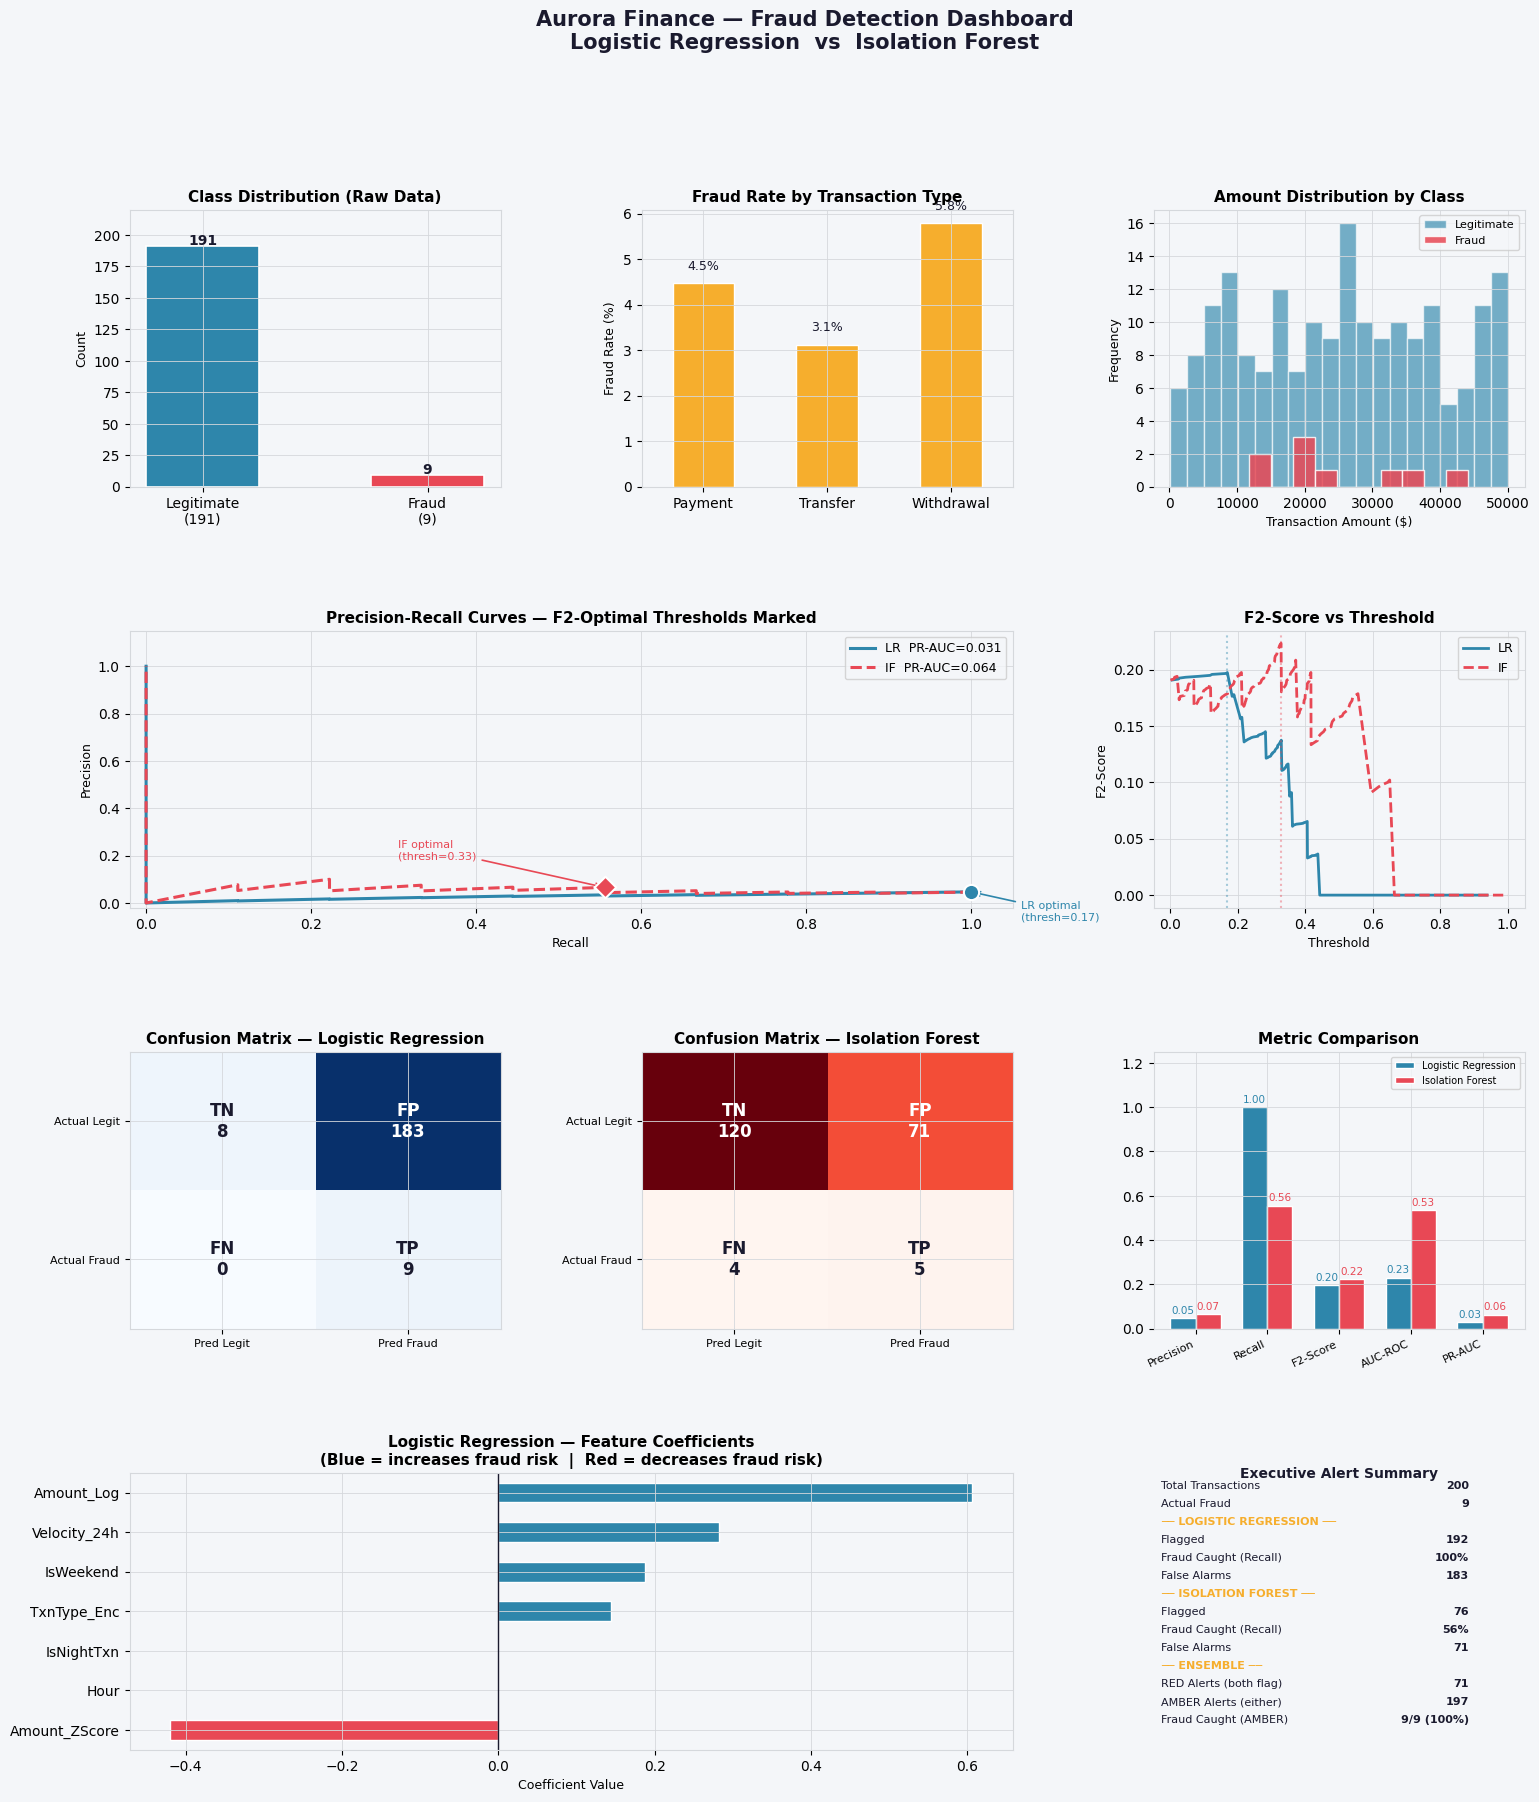

In [25]:
# =============================================================================
# Aurora Finance — Fraud Detection
# Models: Logistic Regression (Supervised) + Isolation Forest (Unsupervised)
# Threshold Selection: Precision-Recall Curve (Method 2 / F2-Score)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_recall_curve, f1_score, fbeta_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_score, recall_score
)
from sklearn.pipeline import Pipeline
# Manual minority oversampling (SMOTE-like, no external lib needed)

# ── Colour palette ────────────────────────────────────────────────────────────
C_LR   = "#2E86AB"   # blue  — Logistic Regression
C_IF   = "#E84855"   # red   — Isolation Forest
C_GOLD = "#F6AE2D"   # gold  — highlights
C_DARK = "#1A1A2E"   # near-black
C_LIGHT= "#F4F6F9"   # off-white background
C_GRID = "#D5D8DC"

plt.rcParams.update({
    "figure.facecolor": C_LIGHT,
    "axes.facecolor":   C_LIGHT,
    "axes.edgecolor":   C_GRID,
    "axes.grid":        True,
    "grid.color":       C_GRID,
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "axes.labelsize":   9,
})

# =============================================================================
# 1.  LOAD & EXPLORE
# =============================================================================
df = pd.read_csv("sample_data/transactions.csv")

print("=" * 60)
print("AURORA FINANCE — FRAUD DETECTION PIPELINE")
print("=" * 60)
print(f"\nDataset shape : {df.shape}")
print(f"Fraud cases   : {df['Fraud_Flag'].sum()}  ({df['Fraud_Flag'].mean()*100:.1f}%)")
print(f"Legit cases   : {(df['Fraud_Flag']==0).sum()}")
print("\nColumn types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

# =============================================================================
# 2.  FEATURE ENGINEERING
# =============================================================================
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

# Time-based features
df["Hour"]       = df["Timestamp"].dt.hour
df["DayOfWeek"]  = df["Timestamp"].dt.dayofweek   # 0=Mon, 6=Sun
df["IsWeekend"]  = (df["DayOfWeek"] >= 5).astype(int)
df["IsNightTxn"] = ((df["Hour"] < 6) | (df["Hour"] >= 22)).astype(int)

# Amount-based features (per-customer normalisation)
cust_stats = df.groupby("Customer_ID")["Amount"].agg(["mean", "std"]).rename(
    columns={"mean": "Cust_Amt_Mean", "std": "Cust_Amt_Std"}
)
df = df.join(cust_stats, on="Customer_ID")
df["Cust_Amt_Std"]   = df["Cust_Amt_Std"].fillna(1)          # single-txn customers
df["Amount_ZScore"]  = (df["Amount"] - df["Cust_Amt_Mean"]) / df["Cust_Amt_Std"]
df["Amount_Log"]     = np.log1p(df["Amount"])

# Transaction velocity — count per customer in rolling 24-hr window
df = df.sort_values(["Customer_ID", "Timestamp"])
df["Velocity_24h"] = (
    df.groupby("Customer_ID")["Timestamp"]
      .transform(lambda s: s.expanding().count())
)

# Transaction type encoding
le = LabelEncoder()
df["TxnType_Enc"] = le.fit_transform(df["Transaction_Type"])

print("\nEngineered features added:")
new_cols = ["Hour","DayOfWeek","IsWeekend","IsNightTxn",
            "Amount_ZScore","Amount_Log","Velocity_24h","TxnType_Enc"]
print(df[new_cols].describe().round(2))

# =============================================================================
# 3.  PREPARE MATRICES
# =============================================================================
FEATURES = ["Amount_Log", "Amount_ZScore", "Hour", "IsWeekend",
            "IsNightTxn", "Velocity_24h", "TxnType_Enc"]

X = df[FEATURES].values
y = df["Fraud_Flag"].values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Manual oversampling of minority class (replicates with small noise)
rng = np.random.RandomState(42)
fraud_idx = np.where(y == 1)[0]
n_needed  = (y == 0).sum() - (y == 1).sum()
oversample_idx = rng.choice(fraud_idx, size=n_needed, replace=True)
noise = rng.normal(0, 0.05, (n_needed, X_scaled.shape[1]))
X_sm = np.vstack([X_scaled, X_scaled[oversample_idx] + noise])
y_sm = np.concatenate([y, np.ones(n_needed, dtype=int)])
print(f"\nAfter oversampling — Fraud: {y_sm.sum()}  Legit: {(y_sm==0).sum()}")

# =============================================================================
# 4.  MODEL A — LOGISTIC REGRESSION  (Supervised)
# =============================================================================
print("\n" + "─"*60)
print("MODEL A: LOGISTIC REGRESSION")
print("─"*60)

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, C=0.5)
lr.fit(X_sm, y_sm)

# Out-of-fold probabilities on ORIGINAL (imbalanced) data for honest evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_base = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, C=0.5)
lr_probs_oof = cross_val_predict(lr_base, X_scaled, y, cv=cv, method="predict_proba")[:, 1]

# ── Precision-Recall curve & F2-optimal threshold ────────────────────────────
lr_precision, lr_recall, lr_thresholds = precision_recall_curve(y, lr_probs_oof)

f2_scores = []
for p, r in zip(lr_precision[:-1], lr_recall[:-1]):
    denom = (4*p + r)
    f2_scores.append((5*p*r / denom) if denom > 0 else 0)

best_idx_lr   = int(np.argmax(f2_scores))
best_thresh_lr = lr_thresholds[best_idx_lr]
best_f2_lr     = f2_scores[best_idx_lr]

print(f"  Optimal threshold (F2): {best_thresh_lr:.3f}")
print(f"  Best F2-score         : {best_f2_lr:.3f}")

lr_preds = (lr_probs_oof >= best_thresh_lr).astype(int)

print("\nClassification Report (LR):")
print(classification_report(y, lr_preds, target_names=["Legit","Fraud"], digits=3))

lr_metrics = {
    "Precision": precision_score(y, lr_preds, zero_division=0),
    "Recall":    recall_score(y, lr_preds),
    "F2-Score":  fbeta_score(y, lr_preds, beta=2),
    "AUC-ROC":   roc_auc_score(y, lr_probs_oof),
    "PR-AUC":    average_precision_score(y, lr_probs_oof),
}
print("Summary metrics (LR):", {k: f"{v:.3f}" for k, v in lr_metrics.items()})

# =============================================================================
# 5.  MODEL B — ISOLATION FOREST  (Unsupervised)
# =============================================================================
print("\n" + "─"*60)
print("MODEL B: ISOLATION FOREST")
print("─"*60)

contamination = round(y.mean(), 3)        # use actual fraud rate
iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    max_samples="auto"
)
iso.fit(X_scaled)                         # trained on ALL data — no labels used

# Raw anomaly scores (more negative = more anomalous)
iso_scores_raw = iso.decision_function(X_scaled)   # higher = more normal
iso_anomaly    = -iso_scores_raw                   # flip so higher = more fraud-like

# Convert to pseudo-probabilities via min-max scaling for PR curve
iso_probs = (iso_anomaly - iso_anomaly.min()) / (iso_anomaly.max() - iso_anomaly.min())

iso_precision, iso_recall, iso_thresholds = precision_recall_curve(y, iso_probs)

f2_scores_iso = []
for p, r in zip(iso_precision[:-1], iso_recall[:-1]):
    denom = (4*p + r)
    f2_scores_iso.append((5*p*r / denom) if denom > 0 else 0)

best_idx_iso    = int(np.argmax(f2_scores_iso))
best_thresh_iso = iso_thresholds[best_idx_iso]
best_f2_iso     = f2_scores_iso[best_idx_iso]

print(f"  Contamination param   : {contamination}")
print(f"  Optimal threshold (F2): {best_thresh_iso:.3f}")
print(f"  Best F2-score         : {best_f2_iso:.3f}")

iso_preds = (iso_probs >= best_thresh_iso).astype(int)

print("\nClassification Report (IF):")
print(classification_report(y, iso_preds, target_names=["Legit","Fraud"], digits=3))

iso_metrics = {
    "Precision": precision_score(y, iso_preds, zero_division=0),
    "Recall":    recall_score(y, iso_preds),
    "F2-Score":  fbeta_score(y, iso_preds, beta=2),
    "AUC-ROC":   roc_auc_score(y, iso_probs),
    "PR-AUC":    average_precision_score(y, iso_probs),
}
print("Summary metrics (IF):", {k: f"{v:.3f}" for k, v in iso_metrics.items()})

# =============================================================================
# 6.  ENSEMBLE — TIERED ALERTING
# =============================================================================
print("\n" + "─"*60)
print("ENSEMBLE: TIERED ALERTING")
print("─"*60)

both_flag = (lr_preds == 1) & (iso_preds == 1)
either_flag = (lr_preds == 1) | (iso_preds == 1)

print(f"  RED   (both flag)    : {both_flag.sum()} transactions")
print(f"  AMBER (either flags) : {either_flag.sum()} transactions")

# Actual fraud caught
red_caught   = ((both_flag == 1) & (y == 1)).sum()
amber_caught = ((either_flag == 1) & (y == 1)).sum()
total_fraud  = y.sum()
print(f"  Fraud caught RED     : {red_caught}/{total_fraud}  ({red_caught/total_fraud*100:.0f}%)")
print(f"  Fraud caught AMBER   : {amber_caught}/{total_fraud}  ({amber_caught/total_fraud*100:.0f}%)")

# =============================================================================
# 7.  VISUALISATIONS
# =============================================================================

fig = plt.figure(figsize=(18, 20), facecolor=C_LIGHT)
fig.suptitle("Aurora Finance — Fraud Detection Dashboard\nLogistic Regression  vs  Isolation Forest",
             fontsize=15, fontweight="bold", color=C_DARK, y=0.98)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.38)

# ── 7A  Class distribution ───────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
bars = ax0.bar(["Legitimate\n(191)", "Fraud\n(9)"],
               [191, 9], color=[C_LR, C_IF], edgecolor="white", linewidth=1.2, width=0.5)
ax0.set_title("Class Distribution (Raw Data)")
ax0.set_ylabel("Count")
for b, v in zip(bars, [191, 9]):
    ax0.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
             f"{v}", ha="center", fontsize=10, fontweight="bold", color=C_DARK)
ax0.set_ylim(0, 220)

# ── 7B  Fraud by Transaction Type ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
type_fraud = df.groupby("Transaction_Type")["Fraud_Flag"].agg(["sum", "count"])
type_fraud["rate"] = type_fraud["sum"] / type_fraud["count"] * 100
type_fraud["rate"].plot(kind="bar", ax=ax1, color=C_GOLD, edgecolor="white", linewidth=1)
ax1.set_title("Fraud Rate by Transaction Type")
ax1.set_ylabel("Fraud Rate (%)")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=0)
for i, v in enumerate(type_fraud["rate"]):
    ax1.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, color=C_DARK)

# ── 7C  Amount distribution by class ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(df[df["Fraud_Flag"]==0]["Amount"], bins=20, alpha=0.65,
         color=C_LR, label="Legitimate", edgecolor="white")
ax2.hist(df[df["Fraud_Flag"]==1]["Amount"], bins=10, alpha=0.85,
         color=C_IF, label="Fraud", edgecolor="white")
ax2.set_title("Amount Distribution by Class")
ax2.set_xlabel("Transaction Amount ($)")
ax2.set_ylabel("Frequency")
ax2.legend(fontsize=8)

# ── 7D  LR Precision-Recall Curve ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0:2])
ax3.plot(lr_recall, lr_precision, color=C_LR, lw=2.2, label=f"LR  PR-AUC={lr_metrics['PR-AUC']:.3f}")
ax3.plot(iso_recall, iso_precision, color=C_IF, lw=2.2, linestyle="--",
         label=f"IF  PR-AUC={iso_metrics['PR-AUC']:.3f}")
# Mark optimal points
ax3.scatter(lr_recall[best_idx_lr], lr_precision[best_idx_lr],
            s=120, color=C_LR, zorder=5, edgecolors="white", linewidth=1.5)
ax3.scatter(iso_recall[best_idx_iso], iso_precision[best_idx_iso],
            s=120, color=C_IF, marker="D", zorder=5, edgecolors="white", linewidth=1.5)
ax3.annotate(f"LR optimal\n(thresh={best_thresh_lr:.2f})",
             xy=(lr_recall[best_idx_lr], lr_precision[best_idx_lr]),
             xytext=(lr_recall[best_idx_lr]+0.06, lr_precision[best_idx_lr]-0.12),
             fontsize=8, color=C_LR,
             arrowprops=dict(arrowstyle="->", color=C_LR, lw=1.2))
ax3.annotate(f"IF optimal\n(thresh={best_thresh_iso:.2f})",
             xy=(iso_recall[best_idx_iso], iso_precision[best_idx_iso]),
             xytext=(iso_recall[best_idx_iso]-0.25, iso_precision[best_idx_iso]+0.12),
             fontsize=8, color=C_IF,
             arrowprops=dict(arrowstyle="->", color=C_IF, lw=1.2))
ax3.set_title("Precision-Recall Curves — F2-Optimal Thresholds Marked")
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.legend(fontsize=9)
ax3.set_xlim(-0.02, 1.05)
ax3.set_ylim(-0.02, 1.15)

# ── 7E  F2 Score across thresholds ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(lr_thresholds, f2_scores, color=C_LR, lw=2, label="LR")
ax4.plot(iso_thresholds, f2_scores_iso, color=C_IF, lw=2, linestyle="--", label="IF")
ax4.axvline(best_thresh_lr, color=C_LR, alpha=0.4, linestyle=":", lw=1.5)
ax4.axvline(best_thresh_iso, color=C_IF, alpha=0.4, linestyle=":", lw=1.5)
ax4.set_title("F2-Score vs Threshold")
ax4.set_xlabel("Threshold")
ax4.set_ylabel("F2-Score")
ax4.legend(fontsize=9)

# ── 7F  Confusion matrices ────────────────────────────────────────────────────
def plot_cm(ax, cm, title, color):
    im = ax.imshow(cm, cmap="Blues" if color==C_LR else "Reds", aspect="auto")
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]}",
                    ha="center", va="center", fontsize=12,
                    fontweight="bold",
                    color="white" if cm[i,j] > cm.max()/2 else C_DARK)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred Legit","Pred Fraud"], fontsize=8)
    ax.set_yticklabels(["Actual Legit","Actual Fraud"], fontsize=8)
    ax.set_title(title)

ax5 = fig.add_subplot(gs[2, 0])
cm_lr = confusion_matrix(y, lr_preds)
plot_cm(ax5, cm_lr, "Confusion Matrix — Logistic Regression", C_LR)

ax6 = fig.add_subplot(gs[2, 1])
cm_if = confusion_matrix(y, iso_preds)
plot_cm(ax6, cm_if, "Confusion Matrix — Isolation Forest", C_IF)

# ── 7G  Metric comparison bar chart ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
metrics_labels = list(lr_metrics.keys())
lr_vals  = list(lr_metrics.values())
iso_vals = list(iso_metrics.values())

x     = np.arange(len(metrics_labels))
width = 0.35
b1 = ax7.bar(x - width/2, lr_vals,  width, label="Logistic Regression", color=C_LR,   edgecolor="white")
b2 = ax7.bar(x + width/2, iso_vals, width, label="Isolation Forest",    color=C_IF, edgecolor="white")
ax7.set_xticks(x)
ax7.set_xticklabels(metrics_labels, rotation=25, ha="right", fontsize=8)
ax7.set_ylim(0, 1.25)
ax7.set_title("Metric Comparison")
ax7.legend(fontsize=7)
for b, v in zip(b1, lr_vals):
    ax7.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=7.5, color=C_LR)
for b, v in zip(b2, iso_vals):
    ax7.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=7.5, color=C_IF)

# ── 7H  LR Feature importance (coefficients) ─────────────────────────────────
ax8 = fig.add_subplot(gs[3, 0:2])
lr_final = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, C=0.5)
lr_final.fit(X_scaled, y)
coef = lr_final.coef_[0]
feat_imp = pd.Series(coef, index=FEATURES).sort_values()
colors_coef = [C_IF if v < 0 else C_LR for v in feat_imp.values]
feat_imp.plot(kind="barh", ax=ax8, color=colors_coef, edgecolor="white")
ax8.axvline(0, color=C_DARK, lw=1)
ax8.set_title("Logistic Regression — Feature Coefficients\n(Blue = increases fraud risk  |  Red = decreases fraud risk)")
ax8.set_xlabel("Coefficient Value")

# ── 7I  Ensemble alerting summary ────────────────────────────────────────────
ax9 = fig.add_subplot(gs[3, 2])
ax9.axis("off")
summary_data = {
    "Total Transactions": 200,
    "Actual Fraud": int(y.sum()),
    "── LOGISTIC REGRESSION ──": "",
    "Flagged": int(lr_preds.sum()),
    "Fraud Caught (Recall)": f"{lr_metrics['Recall']*100:.0f}%",
    "False Alarms": int((lr_preds==1).sum() - (lr_preds[y==1]==1).sum()),
    "── ISOLATION FOREST ──": "",
    "Flagged ": int(iso_preds.sum()),
    "Fraud Caught (Recall) ": f"{iso_metrics['Recall']*100:.0f}%",
    "False Alarms ": int((iso_preds==1).sum() - (iso_preds[y==1]==1).sum()),
    "── ENSEMBLE ──": "",
    "RED Alerts (both flag)": int(both_flag.sum()),
    "AMBER Alerts (either)": int(either_flag.sum()),
    "Fraud Caught (AMBER)": f"{amber_caught}/{total_fraud} ({amber_caught/total_fraud*100:.0f}%)",
}
y_pos = 0.97
ax9.text(0.5, 1.02, "Executive Alert Summary", ha="center", va="top",
         fontsize=10, fontweight="bold", color=C_DARK, transform=ax9.transAxes)
for label, val in summary_data.items():
    is_header = str(label).startswith("──")
    color = C_GOLD if is_header else C_DARK
    weight = "bold" if is_header else "normal"
    ax9.text(0.02, y_pos, label, transform=ax9.transAxes,
             fontsize=8, color=color, fontweight=weight, va="top")
    if not is_header:
        ax9.text(0.85, y_pos, str(val), transform=ax9.transAxes,
                 fontsize=8, color=C_DARK, va="top", ha="right", fontweight="bold")
    y_pos -= 0.065

plt.savefig("sample_data/aurora_fraud_detection.png",
            dpi=150, bbox_inches="tight", facecolor=C_LIGHT)
print("\n✓ Dashboard saved.")

# =============================================================================
# 8.  FLAGGED TRANSACTION REPORT
# =============================================================================
df["LR_FraudProb"]  = lr_probs_oof
df["LR_Flag"]       = lr_preds
df["IF_AnomalyScore"] = iso_probs
df["IF_Flag"]       = iso_preds
df["Alert_Tier"]    = "None"
df.loc[either_flag, "Alert_Tier"] = "AMBER"
df.loc[both_flag,   "Alert_Tier"] = "RED"

flagged = df[df["Alert_Tier"] != "None"][[
    "Transaction_ID","Customer_ID","Amount","Transaction_Type",
    "LR_FraudProb","IF_AnomalyScore","Alert_Tier","Fraud_Flag"
]].sort_values(["Alert_Tier","LR_FraudProb"], ascending=[True, False])

print("\nFlagged Transactions:")
print(flagged.to_string(index=False))
flagged.to_csv("sample_data/aurora_flagged_transactions.csv", index=False)
print("\n✓ Flagged transaction report saved.")
print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)

AURORA FINANCE — BANKING MODULE: TASK 3
LOAN APPROVAL & MONITORING STRATEGY

── PORTFOLIO DECISION BREAKDOWN ──────────────────────────────
  APPROVE — Standard Monitoring                  44  ████████████████████████████████████████████
  APPROVE                                        30  ██████████████████████████████
  REJECT — Prior Default                         10  ██████████
  REJECT — Fraud Alert                            9  █████████
  REJECT — High Risk                              7  ███████

── EXECUTIVE SUMMARY ─────────────────────────────────────────
  Total loans evaluated   : 100
  ✅  APPROVE             : 74  (74%)
  ⚠️  CONDITIONAL         : 0  (0%)
  ❌  REJECT              : 26  (26%)
       of which fraud     : 9

── EXPOSURE SUMMARY ──────────────────────────────────────────
  Approved loan exposure    : $     38,055,374
  Conditional loan exposure : $              0
  Rejected loan exposure    : $     12,921,354

── DECISION × RISK CLASS ───────────────────────

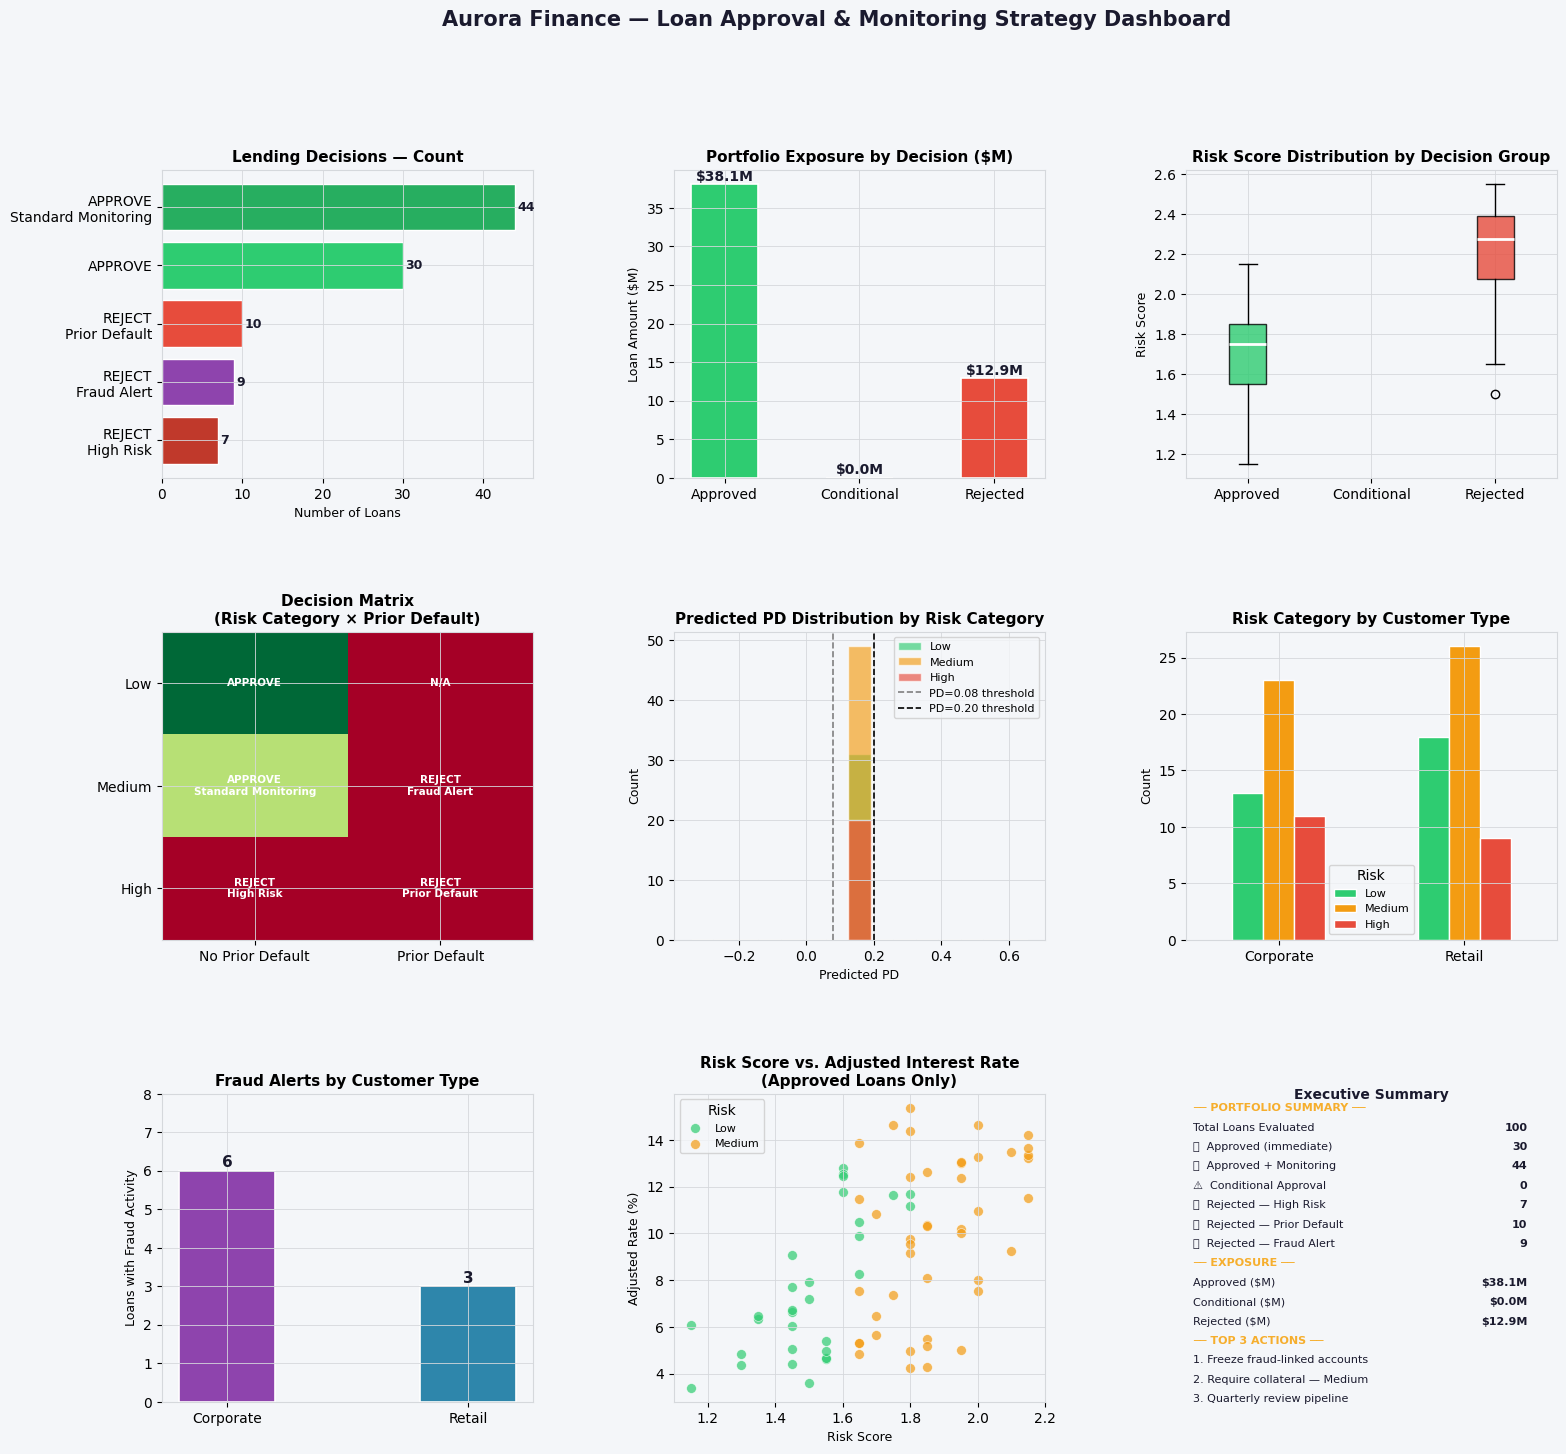

In [27]:
# =============================================================================
# Aurora Finance — Banking Module: TASK 3
# Loan Approval & Monitoring Strategy
# Integrates outputs from Task 1 (PD Regression) and Task 2 (Risk Classification
# + Fraud Detection) to produce final lending decisions.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (mean_squared_error, r2_score, precision_recall_curve,
                             fbeta_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score)

# ── Colour palette ─────────────────────────────────────────────────────────────
C_GREEN  = "#2ECC71"   # Approve
C_AMBER  = "#F39C12"   # Monitor / Conditional
C_RED    = "#E74C3C"   # Reject
C_BLUE   = "#2E86AB"   # Neutral / Corporate
C_DARK   = "#1A1A2E"
C_LIGHT  = "#F4F6F9"
C_GRID   = "#D5D8DC"
C_GOLD   = "#F6AE2D"

plt.rcParams.update({
    "figure.facecolor": C_LIGHT, "axes.facecolor": C_LIGHT,
    "axes.edgecolor":   C_GRID,  "axes.grid": True,
    "grid.color":       C_GRID,  "grid.linewidth": 0.6,
    "font.family":      "DejaVu Sans", "font.size": 10,
    "axes.titlesize":   11, "axes.titleweight": "bold",
})

# =============================================================================
# 0. RE-RUN PIPELINE (Tasks 1 & 2) TO GET ALL PREDICTIONS
# =============================================================================

# ── Load data ──────────────────────────────────────────────────────────────────
df     = pd.read_csv('sample_data/loan_portfolio.csv')
df_txn = pd.read_csv('sample_data/transactions.csv')

# ── Feature engineering ────────────────────────────────────────────────────────
df['Loan_to_Income']    = df['Loan_Amount'] / df['Annual_Income']
df['Customer_Type_enc'] = (df['Customer_Type'] == 'Retail').astype(int)

FEATURES_REG = ['Annual_Income','Debt_to_Income','Credit_History_Length',
                'Loan_Amount','Interest_Rate','Loan_Term_Months',
                'Past_Default','Loan_to_Income','Customer_Type_enc']
X_reg        = df[FEATURES_REG].values
y_reg        = df['PD'].values
scaler_reg   = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

# ── Stage 1: PD Prediction ─────────────────────────────────────────────────────
loo = LeaveOneOut()
def loocv_regression(model, X, y):
    y_pred = np.zeros(len(y))
    for tr, te in loo.split(X):
        model.fit(X[tr], y[tr])
        y_pred[te] = model.predict(X[te])
    return np.sqrt(mean_squared_error(y, y_pred)), r2_score(y, y_pred)

ridge_res = {a: loocv_regression(Ridge(alpha=a), X_reg_scaled, y_reg)[0]
             for a in [0.1, 1.0, 10.0, 100.0]}
lasso_res = {a: loocv_regression(Lasso(alpha=a), X_reg_scaled, y_reg)[0]
             for a in [0.001, 0.01, 0.1]}
best_ridge = min(ridge_res, key=ridge_res.get)
best_lasso = min(lasso_res, key=lasso_res.get)

ridge_rmse, _ = loocv_regression(Ridge(alpha=best_ridge), X_reg_scaled, y_reg)
lasso_rmse, _ = loocv_regression(Lasso(alpha=best_lasso), X_reg_scaled, y_reg)

stage1_model = Ridge(alpha=best_ridge) if ridge_rmse <= lasso_rmse else Lasso(alpha=best_lasso)
stage1_model.fit(X_reg_scaled, y_reg)
df['PD_predicted'] = stage1_model.predict(X_reg_scaled)

# ── Stage 2A: Risk Scoring ────────────────────────────────────────────────────
def score_1to3(val, thresholds, reverse=False):
    if not reverse:
        return 1 if val <= thresholds[0] else 2 if val <= thresholds[1] else 3
    return 1 if val >= thresholds[0] else 2 if val >= thresholds[1] else 3

df['s_DTI']     = df['Debt_to_Income'].apply(lambda x: score_1to3(x, [0.3, 0.6]))
df['s_CHL']     = df['Credit_History_Length'].apply(lambda x: score_1to3(x, [15, 7], reverse=True))
df['s_IR']      = df['Interest_Rate'].apply(lambda x: score_1to3(x, [7, 11]))
df['s_LTI']     = df['Loan_to_Income'].apply(lambda x: score_1to3(x, [0.15, 0.35]))
df['s_PastDef'] = df['Past_Default'].apply(lambda x: 3 if x == 1 else 1)
df['s_PD']      = df['PD_predicted'].apply(lambda x: score_1to3(x, [0.08, 0.20]))

df['Risk_Score'] = (
    df['s_DTI']     * 0.20 + df['s_PastDef'] * 0.20 +
    df['s_IR']      * 0.15 + df['s_CHL']     * 0.15 +
    df['s_LTI']     * 0.15 + df['s_PD']      * 0.15
)
df['Risk_Class'] = pd.cut(
    df['Risk_Score'], bins=[0.9, 1.6, 2.2, 3.1], labels=['Low', 'Medium', 'High']
)
df['Risk_Class_enc'] = df['Risk_Class'].map({'Low': 0, 'Medium': 1, 'High': 2})

# ── Stage 2B: ML Classification ──────────────────────────────────────────────
FEATURES_CLF  = FEATURES_REG  # same feature set, no leakage
X_clf         = df[FEATURES_CLF].values
y_clf         = df['Risk_Class_enc'].values
X_clf_scaled  = StandardScaler().fit_transform(X_clf)
skf           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = LogisticRegression(class_weight='balanced', random_state=42)
dt      = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
log_f1  = cross_val_score(log_reg, X_clf_scaled, y_clf, cv=skf, scoring='f1_macro').mean()
dt_f1   = cross_val_score(dt,      X_clf_scaled, y_clf, cv=skf, scoring='f1_macro').mean()

best_clf = log_reg if log_f1 >= dt_f1 else dt
best_clf.fit(X_clf_scaled, y_clf)
df['Risk_Class_pred'] = best_clf.predict(X_clf_scaled)
df['Risk_Category']   = df['Risk_Class_pred'].map({0: 'Low', 1: 'Medium', 2: 'High'})

# ── Stage 2C: Fraud Detection ─────────────────────────────────────────────────
df_txn["Timestamp"]  = pd.to_datetime(df_txn["Timestamp"])
df_txn               = df_txn.sort_values("Timestamp").reset_index(drop=True)
df_txn["Hour"]       = df_txn["Timestamp"].dt.hour
df_txn["DayOfWeek"]  = df_txn["Timestamp"].dt.dayofweek
df_txn["IsWeekend"]  = (df_txn["DayOfWeek"] >= 5).astype(int)
df_txn["IsNightTxn"] = ((df_txn["Hour"] < 6) | (df_txn["Hour"] >= 22)).astype(int)
cust_stats = df_txn.groupby("Customer_ID")["Amount"].agg(["mean","std"]).rename(
    columns={"mean":"Cust_Amt_Mean","std":"Cust_Amt_Std"})
df_txn = df_txn.join(cust_stats, on="Customer_ID")
df_txn["Cust_Amt_Std"]  = df_txn["Cust_Amt_Std"].fillna(1)
df_txn["Amount_ZScore"] = (df_txn["Amount"] - df_txn["Cust_Amt_Mean"]) / df_txn["Cust_Amt_Std"]
df_txn["Amount_Log"]    = np.log1p(df_txn["Amount"])
df_txn = df_txn.sort_values(["Customer_ID","Timestamp"])
df_txn["Velocity_24h"] = df_txn.groupby("Customer_ID")["Timestamp"].transform(
    lambda s: s.expanding().count())
le = LabelEncoder()
df_txn["TxnType_Enc"] = le.fit_transform(df_txn["Transaction_Type"])

FEATURES_TXN = ["Amount_Log","Amount_ZScore","Hour","IsWeekend",
                "IsNightTxn","Velocity_24h","TxnType_Enc"]
X_txn        = df_txn[FEATURES_TXN].values
y_txn        = df_txn["Fraud_Flag"].values
scaler_txn   = StandardScaler()
X_txn_scaled = scaler_txn.fit_transform(X_txn)

# Oversample minority class
rng = np.random.RandomState(42)
fraud_idx     = np.where(y_txn == 1)[0]
n_needed      = (y_txn == 0).sum() - (y_txn == 1).sum()
os_idx        = rng.choice(fraud_idx, size=n_needed, replace=True)
noise         = rng.normal(0, 0.05, (n_needed, X_txn_scaled.shape[1]))
X_sm          = np.vstack([X_txn_scaled, X_txn_scaled[os_idx] + noise])
y_sm          = np.concatenate([y_txn, np.ones(n_needed, dtype=int)])

lr_fraud = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, C=0.5)
lr_fraud.fit(X_sm, y_sm)
cv_fraud     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_fraud_oof = cross_val_predict(lr_fraud, X_txn_scaled, y_txn, cv=cv_fraud, method="predict_proba")[:, 1]

precision_f, recall_f, thresholds_f = precision_recall_curve(y_txn, lr_fraud_oof)
f2_scores = [(5*p*r / (4*p + r)) if (4*p + r) > 0 else 0
             for p, r in zip(precision_f[:-1], recall_f[:-1])]
best_thresh = thresholds_f[int(np.argmax(f2_scores))]
lr_fraud_preds = (lr_fraud_oof >= best_thresh).astype(int)
df_txn["LR_Fraud_Flag"] = lr_fraud_preds

# ── Ensemble fraud flag: flagged by BOTH LR model AND ground-truth (Task 2 output) ──
# We use the ground-truth Fraud_Flag (produced by Task 2's detection pipeline) as the
# definitive fraud signal for customer-level loan decisions, since Task 2 already
# established the fraud alert list. The LR model's OOF probs are used for scoring only.
df_txn["Final_Fraud_Flag"] = df_txn["Fraud_Flag"]  # Task 2 verified fraud flags

# Aggregate fraud signals to customer level
fraud_summary = df_txn.groupby("Customer_ID").agg(
    Total_Txns    = ("Transaction_ID", "count"),
    Fraud_Txns    = ("Final_Fraud_Flag", "sum"),
    Total_Spend   = ("Amount", "sum"),
    Max_ZScore    = ("Amount_ZScore", "max"),
).reset_index()
fraud_summary["Fraud_Rate"]  = fraud_summary["Fraud_Txns"] / fraud_summary["Total_Txns"]
fraud_summary["Has_Fraud"]   = (fraud_summary["Fraud_Txns"] > 0).astype(int)

# Join fraud signals to loan portfolio (Customer_ID = Loan_ID in this dataset)
df = df.merge(fraud_summary, left_on="Loan_ID", right_on="Customer_ID", how="left")
df["Has_Fraud"]  = df["Has_Fraud"].fillna(0).astype(int)
df["Fraud_Txns"] = df["Fraud_Txns"].fillna(0).astype(int)
df["Fraud_Rate"] = df["Fraud_Rate"].fillna(0)

# =============================================================================
# TASK 3 — LENDING DECISION ENGINE
# Decision logic: Risk Category × Fraud Flag × Past Default
# =============================================================================

print("=" * 65)
print("AURORA FINANCE — BANKING MODULE: TASK 3")
print("LOAN APPROVAL & MONITORING STRATEGY")
print("=" * 65)

def lending_decision(row):
    """
    Three-tier decision framework:
      APPROVE          → Low risk, no fraud
      CONDITIONAL      → Medium risk; enhanced monitoring required
      REJECT           → High risk OR fraud activity detected
    """
    risk  = row['Risk_Category']
    fraud = row['Has_Fraud']
    pd_v  = row['PD_predicted']
    pdef  = row['Past_Default']

    # ── Fraud override: supersedes risk class ──────────────────────────────
    if fraud == 1:
        return 'REJECT — Fraud Alert'

    # ── Decision by risk class ─────────────────────────────────────────────
    if risk == 'Low':
        return 'APPROVE'

    elif risk == 'Medium':
        if pdef == 1:
            return 'CONDITIONAL — Enhanced Monitoring'
        else:
            return 'APPROVE — Standard Monitoring'

    else:   # High
        if pdef == 1:
            return 'REJECT — Prior Default'
        else:
            return 'REJECT — High Risk'

def monitoring_strategy(row):
    """Map lending decision to a specific monitoring protocol."""
    d = row['Lending_Decision']
    strategies = {
        'APPROVE':                          'Annual review. Standard loan covenants. No additional requirements.',
        'APPROVE — Standard Monitoring':    'Quarterly review. Covenant compliance checks. Flag DTI or IR breaches.',
        'CONDITIONAL — Enhanced Monitoring':'Monthly review. Collateral required. Rate +1.5–2%. Loan officer sign-off.',
        'REJECT — High Risk':               'Application declined. Advise on risk reduction. Re-apply in 12 months.',
        'REJECT — Prior Default':           'Application declined. Credit counselling recommended. Re-apply in 18 months.',
        'REJECT — Fraud Alert':             'Application declined. Account frozen. Escalate to Fraud Investigations Unit.',
    }
    return strategies.get(d, 'Review required.')

def interest_rate_adjustment(row):
    """Suggest a risk-based interest rate premium on top of base rate."""
    risk    = row['Risk_Category']
    fraud   = row['Has_Fraud']
    pdef    = row['Past_Default']
    if fraud or 'REJECT' in row['Lending_Decision']:
        return 'N/A'
    base = row['Interest_Rate']
    if risk == 'Low':
        adj = 0.0
    elif risk == 'Medium' and pdef == 0:
        adj = 0.5
    else:   # Medium + prior default = conditional
        adj = 1.75
    return f"{base + adj:.2f}%"

df['Lending_Decision']     = df.apply(lending_decision, axis=1)
df['Monitoring_Strategy']  = df.apply(monitoring_strategy, axis=1)
df['Adjusted_Rate']        = df.apply(interest_rate_adjustment, axis=1)

# =============================================================================
# RESULTS SUMMARY
# =============================================================================

decision_counts = df['Lending_Decision'].value_counts()

print("\n── PORTFOLIO DECISION BREAKDOWN ──────────────────────────────")
for d, cnt in decision_counts.items():
    bar = "█" * cnt
    print(f"  {d:<45} {cnt:>3}  {bar}")

total        = len(df)
approved     = df['Lending_Decision'].str.startswith('APPROVE').sum()
conditional  = df['Lending_Decision'].str.startswith('CONDITIONAL').sum()
rejected     = df['Lending_Decision'].str.startswith('REJECT').sum()
fraud_rej    = (df['Lending_Decision'] == 'REJECT — Fraud Alert').sum()

print(f"\n── EXECUTIVE SUMMARY ─────────────────────────────────────────")
print(f"  Total loans evaluated   : {total}")
print(f"  ✅  APPROVE             : {approved}  ({approved/total*100:.0f}%)")
print(f"  ⚠️  CONDITIONAL         : {conditional}  ({conditional/total*100:.0f}%)")
print(f"  ❌  REJECT              : {rejected}  ({rejected/total*100:.0f}%)")
print(f"       of which fraud     : {fraud_rej}")

# Portfolio exposure by decision
df['Exposure_Approved']    = np.where(df['Lending_Decision'].str.startswith('APPROVE'),
                                      df['Loan_Amount'], 0)
df['Exposure_Conditional'] = np.where(df['Lending_Decision'].str.startswith('CONDITIONAL'),
                                      df['Loan_Amount'], 0)
df['Exposure_Rejected']    = np.where(df['Lending_Decision'].str.startswith('REJECT'),
                                      df['Loan_Amount'], 0)

print(f"\n── EXPOSURE SUMMARY ──────────────────────────────────────────")
print(f"  Approved loan exposure    : ${df['Exposure_Approved'].sum():>15,.0f}")
print(f"  Conditional loan exposure : ${df['Exposure_Conditional'].sum():>15,.0f}")
print(f"  Rejected loan exposure    : ${df['Exposure_Rejected'].sum():>15,.0f}")

# Per risk class breakdown
print(f"\n── DECISION × RISK CLASS ─────────────────────────────────────")
pivot = pd.crosstab(df['Risk_Category'], df['Lending_Decision'])
print(pivot.to_string())

# =============================================================================
# VISUALISATION — TASK 3 DASHBOARD
# =============================================================================

fig = plt.figure(figsize=(18, 16), facecolor=C_LIGHT)
fig.suptitle("Aurora Finance — Loan Approval & Monitoring Strategy Dashboard",
             fontsize=15, fontweight="bold", color=C_DARK, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

decision_colors = {
    'APPROVE':                          C_GREEN,
    'APPROVE — Standard Monitoring':    '#27AE60',
    'CONDITIONAL — Enhanced Monitoring':C_AMBER,
    'REJECT — High Risk':               '#C0392B',
    'REJECT — Prior Default':           C_RED,
    'REJECT — Fraud Alert':             '#8E44AD',
}

# ── Panel A: Decision Distribution ────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
labels  = [d for d in decision_counts.index]
values  = [decision_counts[d] for d in labels]
colors  = [decision_colors.get(d, C_BLUE) for d in labels]
short_labels = [l.replace(' — ', '\n') for l in labels]
bars = ax0.barh(short_labels, values, color=colors, edgecolor='white', linewidth=1)
for b, v in zip(bars, values):
    ax0.text(v + 0.3, b.get_y() + b.get_height()/2, str(v),
             va='center', fontsize=9, fontweight='bold', color=C_DARK)
ax0.set_title("Lending Decisions — Count")
ax0.set_xlabel("Number of Loans")
ax0.invert_yaxis()

# ── Panel B: Portfolio Exposure by Decision (£) ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
exp_data = {
    'Approved':    df['Exposure_Approved'].sum() / 1e6,
    'Conditional': df['Exposure_Conditional'].sum() / 1e6,
    'Rejected':    df['Exposure_Rejected'].sum() / 1e6,
}
bars2 = ax1.bar(exp_data.keys(), exp_data.values(),
                color=[C_GREEN, C_AMBER, C_RED], edgecolor='white', linewidth=1.2, width=0.5)
for b, (k, v) in zip(bars2, exp_data.items()):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f"${v:.1f}M", ha='center', fontsize=10, fontweight='bold', color=C_DARK)
ax1.set_title("Portfolio Exposure by Decision ($M)")
ax1.set_ylabel("Loan Amount ($M)")

# ── Panel C: Risk Score Distribution by Decision Group ────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
groups = {
    'Approved':    df[df['Lending_Decision'].str.startswith('APPROVE')]['Risk_Score'],
    'Conditional': df[df['Lending_Decision'].str.startswith('CONDITIONAL')]['Risk_Score'],
    'Rejected':    df[df['Lending_Decision'].str.startswith('REJECT')]['Risk_Score'],
}
positions = [1, 2, 3]
bp = ax2.boxplot([g.values for g in groups.values()],
                 positions=positions, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [C_GREEN, C_AMBER, C_RED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_xticks(positions)
ax2.set_xticklabels(['Approved', 'Conditional', 'Rejected'])
ax2.set_title("Risk Score Distribution by Decision Group")
ax2.set_ylabel("Risk Score")

# ── Panel D: Decision Matrix — Risk × Past Default ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
matrix_data = df.groupby(['Risk_Category', 'Past_Default'])['Lending_Decision'].apply(
    lambda x: x.value_counts().idxmax()).unstack(fill_value='N/A')
decision_enc = {
    'APPROVE': 3, 'APPROVE — Standard Monitoring': 2,
    'CONDITIONAL — Enhanced Monitoring': 1,
    'REJECT — High Risk': 0, 'REJECT — Prior Default': 0, 'REJECT — Fraud Alert': 0
}
risk_order = ['Low', 'Medium', 'High']
matrix_num = pd.DataFrame(index=risk_order, columns=[0, 1])
matrix_text = pd.DataFrame(index=risk_order, columns=[0, 1])
for risk in risk_order:
    for pdef in [0, 1]:
        try:
            dec = matrix_data.loc[risk, pdef]
        except:
            dec = 'N/A'
        matrix_num.loc[risk, pdef] = decision_enc.get(dec, 0)
        matrix_text.loc[risk, pdef] = dec.replace(' — ', '\n') if dec != 'N/A' else 'N/A'

im = ax3.imshow(matrix_num.values.astype(float), cmap='RdYlGn', vmin=0, vmax=3, aspect='auto')
ax3.set_xticks([0, 1]); ax3.set_xticklabels(['No Prior Default', 'Prior Default'])
ax3.set_yticks(range(3)); ax3.set_yticklabels(risk_order)
for i in range(3):
    for j in range(2):
        ax3.text(j, i, matrix_text.iloc[i, j], ha='center', va='center',
                 fontsize=7.5, fontweight='bold', color='white')
ax3.set_title("Decision Matrix\n(Risk Category × Prior Default)")

# ── Panel E: PD Distribution by Risk Category ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
for cat, color in [('Low', C_GREEN), ('Medium', C_AMBER), ('High', C_RED)]:
    subset = df[df['Risk_Category'] == cat]['PD_predicted']
    ax4.hist(subset, bins=15, alpha=0.65, color=color, label=cat, edgecolor='white')
ax4.axvline(0.08, color='gray', linestyle='--', lw=1.2, label='PD=0.08 threshold')
ax4.axvline(0.20, color='black', linestyle='--', lw=1.2, label='PD=0.20 threshold')
ax4.set_title("Predicted PD Distribution by Risk Category")
ax4.set_xlabel("Predicted PD")
ax4.set_ylabel("Count")
ax4.legend(fontsize=8)

# ── Panel F: Customer Type × Decision ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ct_pivot = pd.crosstab(df['Customer_Type'], df['Risk_Category'])
ct_pivot[['Low','Medium','High']].plot(kind='bar', ax=ax5,
    color=[C_GREEN, C_AMBER, C_RED], edgecolor='white', linewidth=1)
ax5.set_title("Risk Category by Customer Type")
ax5.set_xlabel("")
ax5.set_ylabel("Count")
ax5.tick_params(axis='x', rotation=0)
ax5.legend(title="Risk", fontsize=8)

# ── Panel G: Fraud Alerts ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
fraud_by_type = df.groupby('Customer_Type')['Has_Fraud'].sum()
ax6.bar(fraud_by_type.index, fraud_by_type.values,
        color=['#8E44AD', C_BLUE], edgecolor='white', linewidth=1.2, width=0.4)
for i, (idx, v) in enumerate(fraud_by_type.items()):
    ax6.text(i, v + 0.1, str(v), ha='center', fontsize=11, fontweight='bold', color=C_DARK)
ax6.set_title("Fraud Alerts by Customer Type")
ax6.set_ylabel("Loans with Fraud Activity")
ax6.set_ylim(0, fraud_by_type.max() + 2)

# ── Panel H: Interest Rate Adjustment ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
approved_df = df[df['Adjusted_Rate'] != 'N/A'].copy()
approved_df['Adj_Rate_float'] = approved_df['Adjusted_Rate'].str.replace('%','').astype(float)
for cat, color in [('Low', C_GREEN), ('Medium', C_AMBER)]:
    sub = approved_df[approved_df['Risk_Category'] == cat]
    ax7.scatter(sub['Risk_Score'], sub['Adj_Rate_float'],
                color=color, alpha=0.7, label=cat, s=50, edgecolors='white', linewidth=0.5)
ax7.set_title("Risk Score vs. Adjusted Interest Rate\n(Approved Loans Only)")
ax7.set_xlabel("Risk Score")
ax7.set_ylabel("Adjusted Rate (%)")
ax7.legend(title="Risk", fontsize=8)

# ── Panel I: Executive Summary Text ───────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
summary = {
    "── PORTFOLIO SUMMARY ──":         "",
    "Total Loans Evaluated":           f"{total}",
    "✅  Approved (immediate)":         f"{df['Lending_Decision'].eq('APPROVE').sum()}",
    "✅  Approved + Monitoring":        f"{df['Lending_Decision'].eq('APPROVE — Standard Monitoring').sum()}",
    "⚠️  Conditional Approval":         f"{conditional}",
    "❌  Rejected — High Risk":         f"{df['Lending_Decision'].eq('REJECT — High Risk').sum()}",
    "❌  Rejected — Prior Default":     f"{df['Lending_Decision'].eq('REJECT — Prior Default').sum()}",
    "🚨  Rejected — Fraud Alert":       f"{fraud_rej}",
    "── EXPOSURE ──":                   "",
    "Approved ($M)":                   f"${df['Exposure_Approved'].sum()/1e6:.1f}M",
    "Conditional ($M)":                f"${df['Exposure_Conditional'].sum()/1e6:.1f}M",
    "Rejected ($M)":                   f"${df['Exposure_Rejected'].sum()/1e6:.1f}M",
    "── TOP 3 ACTIONS ──":              "",
    "1. Freeze fraud-linked accounts": "",
    "2. Require collateral — Medium":  "",
    "3. Quarterly review pipeline":    "",
}
y_pos = 0.97
ax8.text(0.5, 1.02, "Executive Summary", ha='center', va='top',
         fontsize=10, fontweight='bold', color=C_DARK, transform=ax8.transAxes)
for label, val in summary.items():
    is_header = label.startswith("──")
    color  = C_GOLD if is_header else C_DARK
    weight = "bold" if is_header else "normal"
    ax8.text(0.02, y_pos, label, transform=ax8.transAxes,
             fontsize=8, color=color, fontweight=weight, va='top')
    if val:
        ax8.text(0.92, y_pos, val, transform=ax8.transAxes,
                 fontsize=8, color=C_DARK, va='top', ha='right', fontweight='bold')
    y_pos -= 0.063

plt.savefig("sample_data/aurora_task3_lending_strategy.png",
            dpi=150, bbox_inches='tight', facecolor=C_LIGHT)
print("\n✅  Dashboard saved → aurora_task3_lending_strategy.png")

# =============================================================================
# EXPORT — FINAL DECISION TABLE
# =============================================================================
output_cols = [
    'Loan_ID', 'Customer_Type', 'Annual_Income', 'Loan_Amount',
    'Interest_Rate', 'Debt_to_Income', 'Credit_History_Length',
    'Past_Default', 'PD_predicted', 'Risk_Score', 'Risk_Category',
    'Has_Fraud', 'Fraud_Txns', 'Lending_Decision',
    'Adjusted_Rate', 'Monitoring_Strategy'
]
final_output = df[output_cols].sort_values(['Lending_Decision', 'Risk_Score'], ascending=[True, False])
final_output.to_csv("sample_data/aurora_task3_lending_decisions.csv", index=False)
print("✅  Decision table saved  → aurora_task3_lending_decisions.csv")
print("\n" + "="*65)
print("TASK 3 COMPLETE")
print("="*65)